# DSA 210 Project - Data Collection, EDA, and Hypothesis Testing

## Project Title
Analyzing and Predicting Student Academic Performance

## Objective
The aim of this project is to analyze the factors affecting student academic performance and prepare the dataset for the machine learning stage. In this notebook, I perform data collection, data cleaning, exploratory data analysis, and hypothesis testing on the student academic performance dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 1. Data Collection

The dataset used in this project is the **xAPI-Edu-Data** dataset, which contains student demographic, behavioral, and academic performance information. It was obtained from Kaggle and stored locally in the project folder.

The dataset includes variables such as classroom participation, visited learning resources, discussion activity, parent survey responses, absence days, and performance class.

In [2]:
df = pd.read_csv("xAPI-Edu-Data.csv")
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


# 2. Dataset Overview

In this section, I examine the size, structure, and variable types of the dataset in order to better understand the data before analysis.

In [3]:
print("Shape of the dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of the dataset: (480, 17)

Column names:
['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [5]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [6]:
df.describe(include="object")

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
count,480,480,480,480,480,480,480,480,480,480,480,480,480
unique,2,14,14,3,10,3,12,2,2,2,2,2,3
top,M,KW,KuwaIT,MiddleSchool,G-02,A,IT,F,Father,Yes,Good,Under-7,M
freq,305,179,180,248,147,283,95,245,283,270,292,289,211


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicated rows:", df.duplicated().sum())

Missing values in each column:
gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

Number of duplicated rows: 2


## Overview Comments

The dataset contains 480 observations and 17 variables. It includes both categorical and numerical features, which makes it appropriate for exploratory data analysis and machine learning. There are no missing values in the dataset, but there are duplicated rows that should be removed before continuing the analysis.

# 3. Data Cleaning and Preprocessing

In this section, duplicated rows are removed and the target variable is made easier to interpret.

In [8]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (478, 17)


In [9]:
print(df["Class"].value_counts())

Class
M    211
H    142
L    125
Name: count, dtype: int64


In [10]:
class_map = {"L": "Low", "M": "Middle", "H": "High"}
df["Class_Label"] = df["Class"].map(class_map)

df[["Class", "Class_Label"]].head()

,Class,Class_Label
0,M,Middle
1,M,Middle
2,L,Low
3,L,Low
4,M,Middle


The original target variable is represented by the labels **L**, **M**, and **H**. For easier interpretation during analysis, these categories are mapped to **Low**, **Middle**, and **High**.

# 4. Exploratory Data Analysis

In this section, I explore the distributions of important variables and investigate how student behaviors and background factors may be related to academic performance.

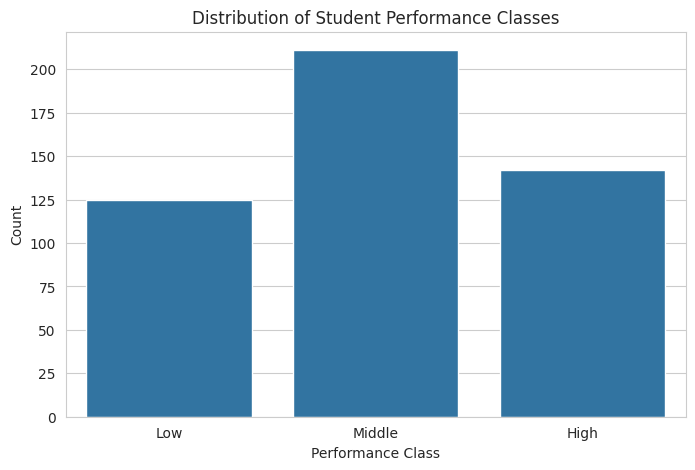

In [11]:
sns.countplot(data=df, x="Class_Label", order=["Low", "Middle", "High"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Class")
plt.ylabel("Count")
plt.show()

This plot shows the distribution of student performance classes in the dataset. It helps identify whether the target variable is balanced or whether one class appears more frequently than the others.

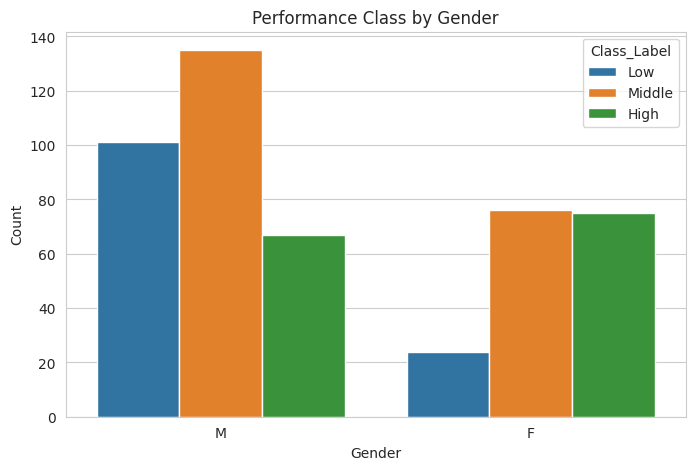

In [12]:
sns.countplot(data=df, x="gender", hue="Class_Label", hue_order=["Low", "Middle", "High"])
plt.title("Performance Class by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

This visualization compares academic performance across male and female students. It gives an initial idea about whether gender may have a visible relationship with student success.

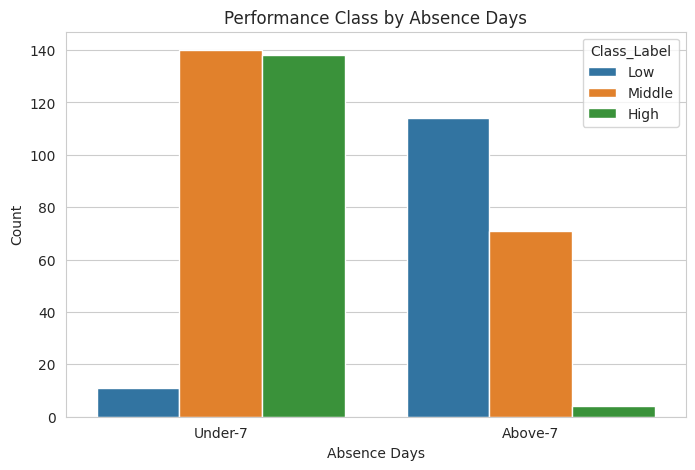

In [13]:
sns.countplot(data=df, x="StudentAbsenceDays", hue="Class_Label", hue_order=["Low", "Middle", "High"])
plt.title("Performance Class by Absence Days")
plt.xlabel("Absence Days")
plt.ylabel("Count")
plt.show()

Attendance is expected to be one of the most important factors affecting academic performance. This graph helps show whether students with more absences tend to belong to lower performance categories.

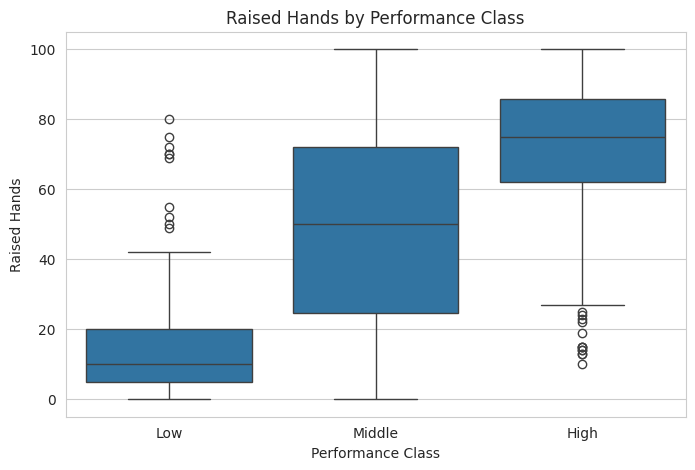

In [14]:
sns.boxplot(data=df, x="Class_Label", y="raisedhands", order=["Low", "Middle", "High"])
plt.title("Raised Hands by Performance Class")
plt.xlabel("Performance Class")
plt.ylabel("Raised Hands")
plt.show()

This plot shows classroom participation levels for different performance groups. Students in higher performance categories may be expected to raise their hands more often during class.

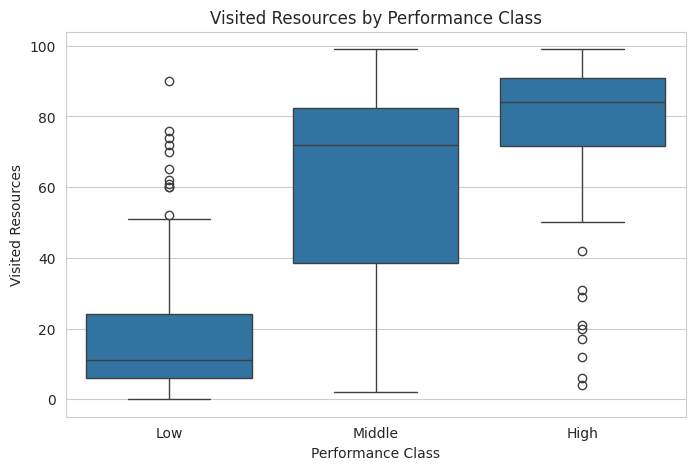

In [15]:
sns.boxplot(data=df, x="Class_Label", y="VisITedResources", order=["Low", "Middle", "High"])
plt.title("Visited Resources by Performance Class")
plt.xlabel("Performance Class")
plt.ylabel("Visited Resources")
plt.show()

This graph examines whether students who use more learning resources tend to perform better academically. Resource usage may be an important indicator of student engagement.

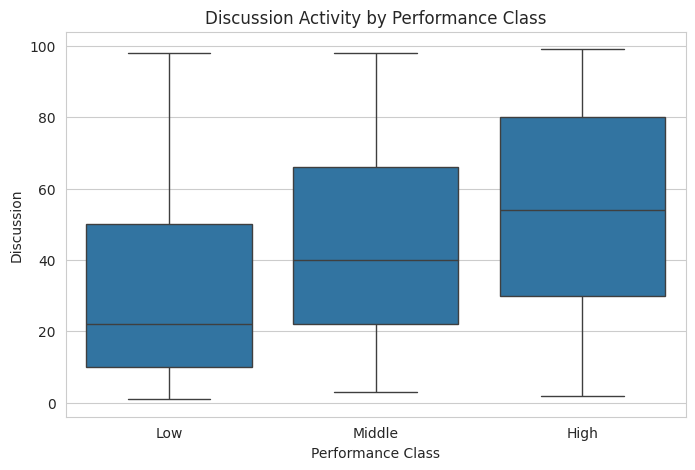

In [16]:
sns.boxplot(data=df, x="Class_Label", y="Discussion", order=["Low", "Middle", "High"])
plt.title("Discussion Activity by Performance Class")
plt.xlabel("Performance Class")
plt.ylabel("Discussion")
plt.show()

Discussion activity may reflect how actively a student participates in the learning process. This plot helps compare discussion levels across performance groups.

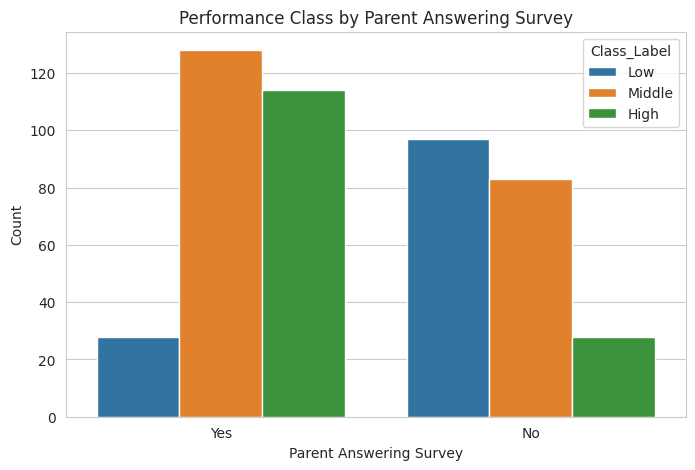

In [17]:
sns.countplot(data=df, x="ParentAnsweringSurvey", hue="Class_Label", hue_order=["Low", "Middle", "High"])
plt.title("Performance Class by Parent Answering Survey")
plt.xlabel("Parent Answering Survey")
plt.ylabel("Count")
plt.show()

This graph shows whether parental involvement, measured through survey responses, may be related to student success.

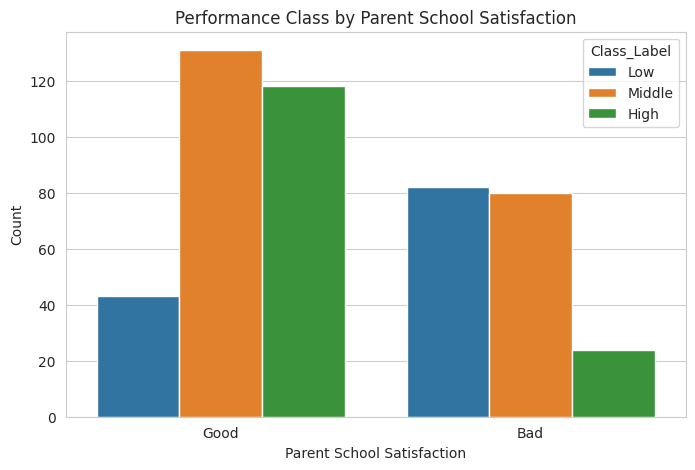

In [18]:
sns.countplot(data=df, x="ParentschoolSatisfaction", hue="Class_Label", hue_order=["Low", "Middle", "High"])
plt.title("Performance Class by Parent School Satisfaction")
plt.xlabel("Parent School Satisfaction")
plt.ylabel("Count")
plt.show()

This visualization explores whether parent satisfaction with the school is associated with the academic performance of students.

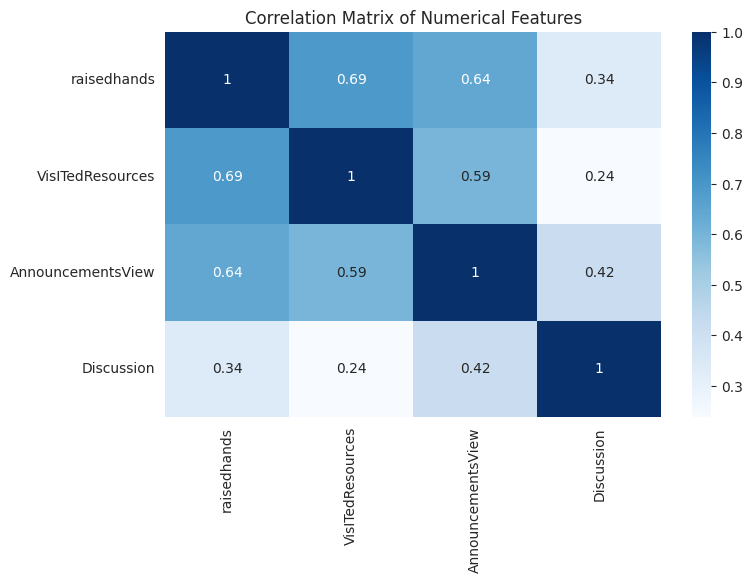

In [19]:
numeric_cols = ["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

The correlation matrix summarizes the relationships between the numerical engagement variables in the dataset. This is useful for understanding whether some student behaviors tend to increase together.

# 5. Hypothesis Testing

In this section, I apply statistical hypothesis testing to examine whether some of the observed relationships are statistically significant.

## Hypothesis Test 1: Absence Days and Performance Class

- **H0:** StudentAbsenceDays and Class are independent.
- **H1:** StudentAbsenceDays and Class are associated.

Since both variables are categorical, a **Chi-Square Test of Independence** is used.

In [20]:
contingency_absence = pd.crosstab(df["StudentAbsenceDays"], df["Class_Label"])
contingency_absence

Class_Label,High,Low,Middle
StudentAbsenceDays,,,
Above-7,4,114,71
Under-7,138,11,140


In [21]:
chi2, p, dof, expected = chi2_contingency(contingency_absence)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("Result: Reject H0. There is a significant relationship between absence days and performance class.")
else:
    print("Result: Fail to reject H0. No significant relationship was found.")

Chi-square statistic: 222.71363302015305
p-value: 4.348596053268476e-49
Degrees of freedom: 2
Result: Reject H0. There is a significant relationship between absence days and performance class.


This test evaluates whether absence patterns are statistically associated with academic performance. If the p-value is below 0.05, the relationship is considered significant.

## Hypothesis Test 2: Parent Answering Survey and Performance Class

- **H0:** ParentAnsweringSurvey and Class are independent.
- **H1:** ParentAnsweringSurvey and Class are associated.

Since both variables are categorical, a **Chi-Square Test of Independence** is used again.

In [22]:
contingency_parent = pd.crosstab(df["ParentAnsweringSurvey"], df["Class_Label"])
contingency_parent

Class_Label,High,Low,Middle
ParentAnsweringSurvey,,,
No,28,97,83
Yes,114,28,128


In [23]:
chi2, p, dof, expected = chi2_contingency(contingency_parent)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("Result: Reject H0. There is a significant relationship between parent survey response and performance class.")
else:
    print("Result: Fail to reject H0. No significant relationship was found.")

Chi-square statistic: 93.29745273106617
p-value: 5.504470538968544e-21
Degrees of freedom: 2
Result: Reject H0. There is a significant relationship between parent survey response and performance class.


This test investigates whether parental engagement is associated with student academic performance.

## Hypothesis Test 3: Raised Hands and Performance Class

- **H0:** The mean raisedhands values are equal across performance classes.
- **H1:** At least one performance class has a different mean raisedhands value.

Since the variable **raisedhands** is numerical and performance class has three groups, a **One-Way ANOVA** test is used.

In [24]:
low_group = df[df["Class_Label"] == "Low"]["raisedhands"]
mid_group = df[df["Class_Label"] == "Middle"]["raisedhands"]
high_group = df[df["Class_Label"] == "High"]["raisedhands"]

f_stat, p_value = f_oneway(low_group, mid_group, high_group)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0. At least one group has a different mean raisedhands value.")
else:
    print("Result: Fail to reject H0. No significant difference was found.")

F-statistic: 174.50347148632437
p-value: 1.5175758915699368e-57
Result: Reject H0. At least one group has a different mean raisedhands value.


This test checks whether classroom participation differs significantly across low, middle, and high performance groups.

## Hypothesis Test 4: Visited Resources and Performance Class

- **H0:** The mean VisITedResources values are equal across performance classes.
- **H1:** At least one performance class has a different mean VisITedResources value.

A **One-Way ANOVA** test is used for this comparison.

In [25]:
low_group = df[df["Class_Label"] == "Low"]["VisITedResources"]
mid_group = df[df["Class_Label"] == "Middle"]["VisITedResources"]
high_group = df[df["Class_Label"] == "High"]["VisITedResources"]

f_stat, p_value = f_oneway(low_group, mid_group, high_group)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0. At least one group has a different mean visited resources value.")
else:
    print("Result: Fail to reject H0. No significant difference was found.")

F-statistic: 226.4357703818633
p-value: 8.63707823412816e-70
Result: Reject H0. At least one group has a different mean visited resources value.


This test evaluates whether learning resource usage differs significantly among student performance groups.

# 6. Conclusion

In this stage of the project, I collected the dataset, examined its structure, cleaned duplicated records, and performed exploratory data analysis. The visualizations suggest that factors such as attendance, classroom participation, learning resource usage, and parental involvement may be related to academic performance.

In addition, hypothesis testing was used to evaluate whether these relationships are statistically significant. The findings from this notebook provide a solid foundation for the next stage of the project, where machine learning models will be applied to predict student performance.

In [26]:
print("Notebook completed successfully.")

Notebook completed successfully.
